# Contexto
1. Paises seleccinados: Colombia (COL), Mexico (MEX), España (ESP), Argentina (ARG), Estados unidos (USA)
2. Inicadores objeto de analisis: 
    - NY.GDP.PCAP.CD: PIB per capita (USD actuales).
    - SP.POP.TOTL: Poblacion total.
    - EG.FEC.RNEW.ZS: Consumo de energía renovable.

URL: https://api.worldbank.org/v2


In [4]:
# Librerias
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [5]:
# Configuración visual
sns.set_theme(style="whitegrid")
BASE_URL = "https://api.worldbank.org/v2"
TIMEOUT = 60

# Reintentos automáticos
session = requests.Session()
retry = Retry(
    total=5,
    connect=5,
    read=5,
    backoff_factor=1,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))
session.mount("http://", HTTPAdapter(max_retries=retry))

print("✅ Entorno listo.")

✅ Entorno listo.


In [6]:
# parametros y descarga
countries = ["COL", "MEX", "ESP", "ARG", "USA"]
indicators = {
    "NY.GDP.PCAP.CD": "gdp_per_capita", # PIB percapita
    "SP.POP.TOTL": "total_population", 
    "EG.FEC.RNEW.ZS": "renewable_energy_pct" # % de energía renovable
}

def fetch_indicator_data(country_codes, indicator_id, start_year=2010, end_year=2024):
    country_path = ";".join(country_codes)
    endpoint = f"{BASE_URL}/country/{country_path}/indicator/{indicator_id}"
    
    page = 1
    all_rows = []
    
    while True:
        params = {
            "format": "json",
            "date": f"{start_year}:{end_year}",
            "per_page": 50,
            "page": page,
        }
        
        response = session.get(endpoint, params=params, timeout=TIMEOUT)
        response.raise_for_status()
        payload = response.json()
        
        if not isinstance(payload, list) or len(payload) < 2:
            break
            
        metadata = payload[0]
        rows = payload[1] if payload[1] is not None else []
        all_rows.extend(rows)
        
        # Control de paginación
        total_pages = int(metadata.get("pages", 1))
        if page >= total_pages:
            break
        page += 1
        
    return all_rows

print("✅ Función de descarga preparada.")


✅ Función de descarga preparada.


In [7]:
# procesar DF individuales
tables = {}

for indicator_id, table_name in indicators.items():
    print(f"Descargando {table_name}...")
    raw_rows = fetch_indicator_data(countries, indicator_id)
    
    if not raw_rows:
        print(f"⚠️ No se encontraron datos para {indicator_id}")
        continue
        
    records = []
    for row in raw_rows:
        records.append({
            "country": row["country"]["value"],
            "year": row["date"],
            "value": row["value"]
        })
    
    df = pd.DataFrame(records)
    
    # Limpieza y conversión
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value", "year"]).copy()
    df["year"] = df["year"].astype(int)
    
    df = df.sort_values(["country", "year"]).reset_index(drop=True)
    tables[table_name] = df

print("✅ DataFrames creados exitosamente.")

Descargando gdp_per_capita...


Descargando total_population...
Descargando renewable_energy_pct...
✅ DataFrames creados exitosamente.


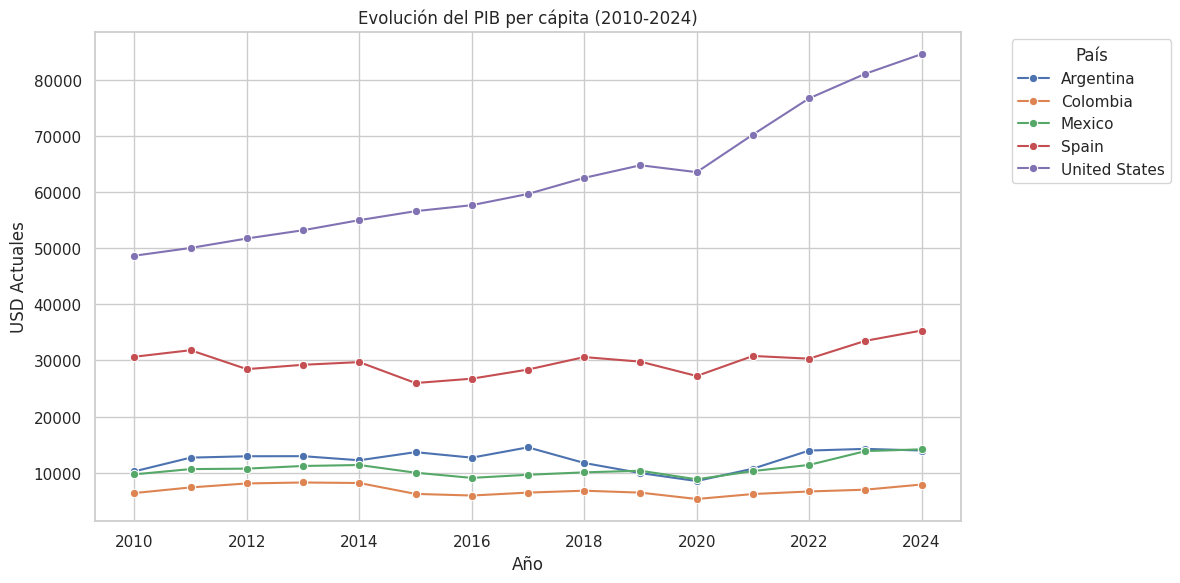

/tmp/ipykernel_900/1910732416.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_recent, x="country", y="value", palette="viridis")


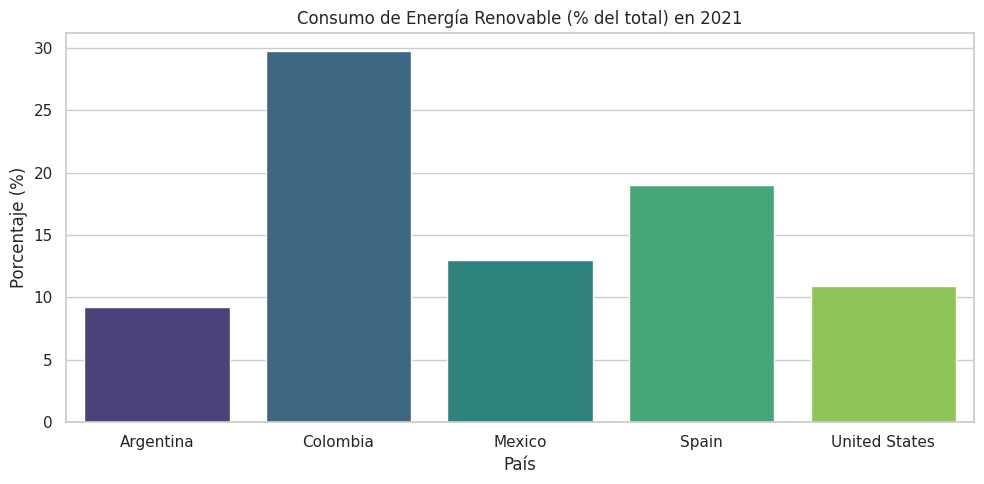

In [9]:
# Gráfico 1: Evolución del PIB
if "gdp_per_capita" in tables:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=tables["gdp_per_capita"], x="year", y="value", hue="country", marker="o")
    plt.title("Evolución del PIB per cápita (2010-2024)")
    plt.ylabel("USD Actuales")
    plt.xlabel("Año")
    plt.legend(title="País", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Gráfico 2: Uso de Energía Renovable (Año más reciente)
if "renewable_energy_pct" in tables:
    # Buscamos el último año disponible con datos para este indicador
    ref_year = tables["renewable_energy_pct"]["year"].max()
    df_recent = tables["renewable_energy_pct"].query("year == @ref_year")
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_recent, x="country", y="value", palette="viridis")
    plt.title(f"Consumo de Energía Renovable (% del total) en {ref_year}")
    plt.ylabel("Porcentaje (%)")
    plt.xlabel("País")
    plt.tight_layout()
    plt.show()

In [18]:
# motor SQLite
engine = create_engine("sqlite:///world_bank_analysis.db")

for table_name, df in tables.items():
    sql_table_name = f"indicator_{table_name}"
    df.to_sql(sql_table_name, engine, if_exists="replace", index=False)
    print(f"Guardado en SQL: {sql_table_name}")

# Validación
print("\n--- Muestra de validación (Población) ---")
print(pd.read_sql("SELECT * FROM indicator_total_population LIMIT 5", engine))

/tmp/ipykernel_900/835344658.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df.to_sql(sql_table_name, engine, if_exists="replace", index=False)


AttributeError: 'Engine' object has no attribute 'cursor'